<a href="https://colab.research.google.com/github/olchan/Samsung-Coding-TEST/blob/main/%5B%EC%9D%B4%EC%BD%94%ED%85%8C%5D_Dynamic_Programming_PART2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 동적 계획법

- DP는 "이미 계산한 것은 다시 계산하지 않는다" 라는 원칙을 바탕으로 계산 결과를 메모리에 저장해 두어 연산 속도를 증가시키는 방법으로, 이 과정을 메모이제이션 (Memoization)이라고 부른다.

> Dynamic Programming을 사용할 수 있는 조건
1. 큰 문제를 작은 문제로 나눌 수 있다.
2. **작은 문제에서 구한 정답은 그것을 포함하는 큰 문제에서 그 값이 그대로 사용된다. 다만, 큰 문제를 해결하는 데 아무 부분문제나 선택되는 것이 아니라, 큰 문제를 최적으로 만드는 부분문제만이 큰 문제의 최적해 계산에 포함되는 것이다. -> 최적성의 원칙 : 어떤 문제의 최적해는 그 문제의 부분문제들의 최적해로 이루어진다. 이는, 전체 최적해는 ‘특정 부분 문제들의 최적해를 조합해서’ 만들어진다는 의미이지, 아무 부분 문제들의 최적해로 만들어진 상위 문제의 해가 항상 전체 최적해를 “보장한다"는 의미는 아니다. 따라서, 특정 부분 문제의 최적해가 전체 최적해를 구성하는 데 항상 사용될 수 있다면, dp로 문제를 풀어나가면 된다.**

> 재귀 함수를 이용하여 DP 소스 코드를 작성하는 방법은 큰 문제를 해결하기 위해 점점 더 작은 문제를 호출한다고 하여 **탑다운 방식**이라고 한다.

- **메모이제이션은 탑다운 방식에 국한되어 사용되는 표현이다.**

- 메모이제이션에는, list 뿐만 아니라 dict 자료형을 이용할 수 도 있다.

> 반대로, 단순히 반복문을 이용하여 소스코드를 작성하는 경우 작은 문제부터 답을 도출하여 큰 문제를 해결한다고 하여 **bottom up 방식**이라고 한다.

- **bottom up 방식에서 사용되는 결과 저장용 list는 "DP table"이라고 부른다.**

> **보통 코딩테스트에서는 “반복문 기반 DP(= bottom-up)”을 훨씬 더 많이 쓴다.** 재귀는 “스택 제한”이 있고, 함수 호출이 계속 발생하기 때문에 잘 사용하지 않는다.

> **특정한 문제를 완전 탐색 알고리즘으로 접근했을 때 시간이 매우 오래 걸린다면, DP를 적용할 수 있는지 결정하기 위해 해결하고자 하는 부분 문제들의 중복 여부를 확인해본다.**


In [ ]:
def fibo(x):
  if x == 1 or x == 2:
    return 1
  return fibo(x-1) + fibo(x-2)

print(fibo(10))
# 위와 같은 코드의 경우, f(n)함수에서 n이 커지면 커질수록 수행 시간이 급격히 늘어남
# 각 층마다 호출하는 함수의 양이 2배이므로 -> O(2^N)

55


> Memoization : 한 번 구한 결과를 메모리 공간에 메모해두고 같은 식을 다시 호출하면 메모한 결과를 그대로 가져오는 기법
- 값을 저장하는 방법으로, Caching이라고도 한다.

In [ ]:
""" 재귀를 활용하는 top down 방식 """
def solve(n):
    # n번째 항까지 저장해야 하므로 크기는 n + 1
    memo = [-1] * (n + 1)

    def fib(k):
        if k <= 1:
            return k
        if memo[k] != -1: # 이미 계산된 적이 있다면
            return memo[k]

        memo[k] = fib(k - 1) + fib(k - 2)
        return memo[k]

    return fib(n)

solve(99)

218922995834555169026

In [ ]:
d = [0] * 100

def fibo(x):
    print('f(' + str(x) + ')', end = " ")
    if x == 1 or x == 2:
        return 1

    if d[x] != 0:
        return d[x]

    elif d[x] == 0:
        d[x] = fibo(x-1) + fibo(x-2)

    return d[x]

print(fibo(9))
"""
fibo(x-1)을 끝까지 먼저 실행한 뒤, 그 다음 fibo(x-2)가 실행되며,
fibo(x-2)는 대부분 ‘이미 계산된 값’을 재사용한다.
"""

f(9) f(8) f(7) f(6) f(5) f(4) f(3) f(2) f(1) f(2) f(3) f(4) f(5) f(6) f(7) 34


In [ ]:
# 재귀 함수를 사용하면 컴퓨터 시스템에서는 함수를 다시 호출했을 때
# 함수가 메모리 상에 적재되기에
# 반복문을 사용한 Dynamic Programming이 재귀에 비해 성능이 더 좋다.

""" 반복문을 활용하는 bottom up 방식 """
n = int(input())
dp = [0] * (n-1)

dp[1] = 1
for i in range(2, n+1):
    dp[i] = dp[i-1] + dp[i-2]

In [ ]:
d = [0] * 100
d[1] = 1
d[2] =1
n = 99

for i in range(3,n+1):
  d[i] = d[i-1] + d[i-2]

print(d[n])

> ### 실전문제 2. 4가지의 연산만으로 최소 연산 횟수로 1 만들기

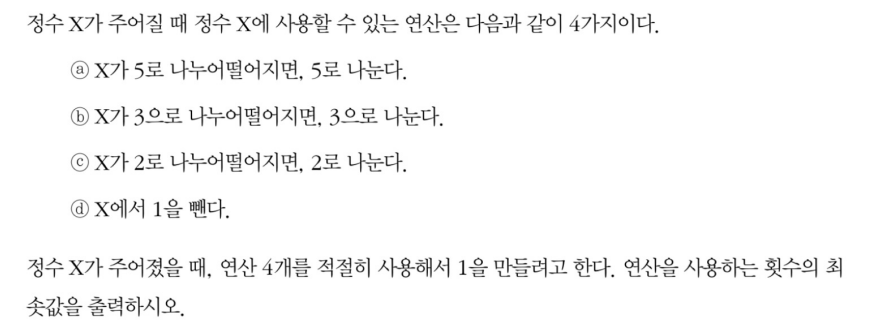

- 최적값 계산:  최단 거리 / 최단 횟수 문제이기에, DP or BFS

- 작은 문제로 쪼개지면서, 같은 계산이 여러 단계에서 반복되기에, dp로 풀 수 있겠다고 생각

> 항상 가장 좋은 선택이 전체에서도 최적이었다면, greedy 이겠지만, 현재 선택이 좋은데도 미래에 최적이 아닌 경우(32)가 있기에, 현재의 선택이 미래에 미치는 영향까지 고려해서 여러 선택지를 비교해야한다.

- 무작정 나눌 수 있는 큰 값으로 나눈다고 해서 최소 연산이 되지는 않는다.
- 26 → 2로 나눔 → 13 → 1 빼기 → 12 → 2로 나눔 → ...
- 26 → 1 빼고 → 25 → 5로 나누기 → 5 → 5로 나누기 → 1


💡 핵심 아이디어

👉 “작은 문제부터 최적해를 쌓아간다”

> 지금 당장의 선택이 전체 최선이 아닐 수 있다 → Greedy 불가
하지만, 부분 문제의 최적해를 전체 최적해를 구성하는 데 사용할 수 있다 → DP 가능

In [ ]:
d[i] = min(
    d[i-1] + 1,
    d[i//2] + 1,
    d[i//3] + 1,
    d[i//5] + 1
)

In [ ]:
# "미래를 고려한다"
# "현재 선택 + 이미 최적화된 결과"를 통해 최적해를 판단

x = int(input())
num = 1

min_list = [0] * 30001
min_list[1] = 0
min_list[2] = 1
min_list[3] = 1
min_list[5] = 1

for i in range(4, x+1):
    min_list[i] = min_list[i-1] + 1
    if i % 2 == 0:
        min_list[i] = min(min_list[i], min_list[i // 2] + 1)
    if i % 3 == 0:
        min_list[i] = min(min_list[i], min_list[i // 3] + 1)
    if i % 5 == 0:
        min_list[i] = min(min_list[i], min_list[i // 5] + 1)

print(min_list[x])

In [ ]:
# for 문의 range를 2부터 하면,
# 모두 다 정상적으로 동작하게 된다.
x = int(input())
num = 1

min_list = [0] * 30001

for i in range(2, x+1):
    min_list[i] = min_list[i-1] + 1
    if i % 2 == 0:
        min_list[i] = min(min_list[i], min_list[i // 2] + 1)
    if i % 3 == 0:
        min_list[i] = min(min_list[i], min_list[i // 3] + 1)
    if i % 5 == 0:
        min_list[i] = min(min_list[i], min_list[i // 5] + 1)

print(min_list[x])

> ### 실전문제 3. 개미 전사

👉 “지금 선택이 이후에도 계속 최적이어야 Greedy”

👉 아래 문제는 그게 아니기 때문에, 모든 선택지를 비교하여 최적해를 갱신해가는 dp를 사용하여 풀어야 한다. 또한, 지금 선택이 이후에 최적해를 구하는 데에도 값의 변화 없이 사용될 수 있다는 점에서도 dp를 통해 풀어야 한다는 것을 알 수 있다.

In [ ]:
n = int(input())
array = list(map(int, input().split()))
d = [0] * 100

d[0] = array[0]
d[1] = max(array[0], array[1])
for i in range(2, n):
    d[i] = max(d[i-2] + array[i], d[i-1]) # 이 2개의 경우가 가능한 모든 경우의 수를 커버함
    # 항상 2개 후보 중에서 큰 값을 고르면 규칙을 만족하면서 큰 값이 됨

print(d[n-1])

> ### 실전문제 4. 바닥 공사

In [ ]:
n = int(input( ))
case = [0] * (n+1)
case[1] = 1

for i in range(2, n+1):
    case[i] = case[i-2] * 2 + case[i-1]

print(case[n] % 796796)

> ### 실전문제 5. 효율적인 화폐 구성

In [ ]:
# greedy에서와 다른 것은 큰 값의 코인이 항상 작은 값의 배수가 아니기에
# greedy 방식으로 풀면 최적해가 아닐 수 있고, 그렇기에 dp를 사용해야한다.

n, m = map(int,input().split())
coin_list = []
for _ in range(n):
    coin_list.append(int(input()))

minimum = coin_list[0]
maximum = max(max(coin_list), m) + 1
min_list = [10001] * maximum
min_list[0] = 0

for num in coin_list:
    min_list[num] = 1
    minimum = min(minimum, coin_list[num])

for i in range(minimum, m+1):
    for num in coin_list:
        if i+num <= m:
            min_list[i + num] = min(min_list[i+num], min_list[i] + 1)

if min_list[m] >= 10001:
    print(-1)
else:
    print(min_list[m])


In [ ]:
# 수정 코드
n, m = map(int,input().split())
coin_list = []
for _ in range(n):
    coin_list.append(int(input()))


maximum = max(max(coin_list), m) + 1
min_list = [10001] * maximum
min_list[0] = 0

for i in range(1, m+1):
    for num in coin_list:
        if i+num <= m:
            if min_list[i+num] != 10001:
                min_list[i + num] = min(min_list[i+num], min_list[i] + 1)

if min_list[m] >= 10001:
    print(-1)
else:
    print(min_list[m])